## Annual Technology Baseline Reporting

### Offshore Wind

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

from time import perf_counter
from pathlib import Path

from waves import Project
from waves.utilities import load_yaml
from waves.utilities import check_ref_sites

from waves.utilities.atb_tools import breakdown_plots

import matplotlib.pyplot as plt


### Check config files based on reference site table.

In [2]:
year = 2023
library_path = Path(f"../library/atb_base_{year}/")

config_path = library_path / "project/config"
ref_site_df = check_ref_sites(config_path, "reference sites.xlsx", verbose=False)

ref_site_df

,Site,Description,Coordinates (internal only),"Plant capacity, MW","Turbine rating, MW",Fixed/floating,Foundation type,Export system,"Spacing between turbines, km","Water depth, m","Export cable length, km","Mean wind speed (at 137 m), m/s","Distance to port, km"
0,1,COWER,NaN,600,12,Fixed,Monopile,HVAC,7D,34,50,9,116
1,2,"High-wind, shallow, close to shore",NaN,600,12,Fixed,Monopile,HVAC,7D,30,40,11,75
2,3,"High-wind, deep, close to shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,40,11,57
3,4,"High-wind, shallow, far from shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,160,11,175
4,5,"High-wind, deep, far from shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,160,11,175
5,6,"Moderate-wind, shallow, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,40,9,75
6,7,"Moderate-wind, deep, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,55,40,9,75
7,8,"Moderate-wind, shallow, far from shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,160,9,175
8,9,"Moderate-wind, deep, far from shore",NaN,1000,12,Fixed,Monopile,HVDC,7D,55,160,9,175
9,10,"Low-wind, shallow, close to shore",NaN,1000,12,Fixed,Monopile,HVAC,7D,30,40,7,75


#### Initialize the projects from dictionary configuration files. 

In [3]:
site_names = []
project_list = []

for _, row in ref_site_df.iterrows():

    base = f"Site{row['Site']}_atb_{year}.yaml"
    site_names.append(base.split('_')[0])

    config = load_yaml(config_path, base)

    config.update({"library_path" : library_path,
                  # "orbit_config" : Path(atb_path / "orbit_config" / f"Site{row['Site']}_atb_{year}_install.yaml").resolve(),
                  # "wombat_config" : Path(atb_path / "wombat_config" / f"Site{row['Site']}_atb_{year}_operations.yaml").resolve(),
                  # "floris_config" : Path(atb_path / "floris_config" / f"Site{row['Site']}_atb_{year}_floris_jensen.yaml").resolve(),
                    }
    )

    start = perf_counter()

    project = Project.from_dict(config)
    project_list.append(project)

    end = perf_counter()

    print(f"{base} loading time: {(end-start):.2f} seconds")


'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MonopileInstallation': ('ScourProtectionInstallation', 0.5), 'OffshoreSubstationInstallation': 0, 'ScourProtectionInstallation': 0, 'TurbineInstallation': ('MonopileInstallation', 0.1)}
ORBIT library intialized at '/Users/nriccobo/GitHub/WAVES/library/atb_base_2023'


Missing data in columns ['bury_speed']; all values will be calculated.FutureWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:116
'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MonopileInstallation': ('ScourProtectionInstallation', 0.5), 'OffshoreSubstationInstallation': 0, 'ScourProtectionInstallation': 0, 'TurbineInstallation': ('MonopileInstallation', 0.1)}
Site1_atb_2023.yaml loading time: 1.54 seconds
{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MonopileInstallation': ('ScourProtectionInstallation', 0.5), 'OffshoreSubstationInstallation': 0, 'ScourProtectionInstallation': 0, 'TurbineInstallation': ('MonopileInstallation', 0.1)}


Missing data in columns ['bury_speed']; all values will be calculated.FutureWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:116
'H' is deprecated and will be removed in a future version, please use 'h' instead.

...

Missing data in columns ['bury_speed']; all values will be calculated.FutureWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:116
'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site20_atb_2023.yaml loading time: 1.32 seconds
{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}


Missing data in columns ['bury_speed']; all values will be calculated.FutureWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:116
'H' is deprecated and will be removed in a future version, please use 'h' instead.

{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site21_atb_2023.yaml loading time: 1.32 seconds
{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
{'ArrayCableInstallation': 0, 'ExportCableInstallation': 0, 'MooredSubInstallation': 0, 'MooringSystemInstallation': 0, 'OffshoreSubstationInstallation': 0}
Site22_atb_2023.yaml loading time: 1.32 seconds


Missing data in columns ['bury_speed']; all values will be calculated.

#### Run Project

In [4]:

id = len(project_list)
for i,p in enumerate(project_list[:id]):

    start1 = perf_counter()
    p.run(
        full_wind_rose=False,  # use the WOMBAT date range
    )
    p.wombat.env.cleanup_log_files()  # Delete logging data from the WOMBAT simulations

    end1 = perf_counter()

    print(f"{site_names[i]} run time: {end1 - start1:,.2f} seconds")

Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].SettingWithCopyWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:760

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:328
invalid value encountered in divideRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:498


Site1 run time: 66.93 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].SettingWithCopyWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:760

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:328
invalid value encountered in divideRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:498


Site2 run time: 67.79 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].SettingWithCopyWarning: /Users/nriccobo/GitHub/WAVES/waves/project.py:760

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copyRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:328
invalid value encountered in divideRuntimeWarning: /opt/anaconda3/envs/waves/lib/python3.10/site-packages/floris/core/wake_deflection/gauss.py:498


...

Site20 run time: 65.24 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site21 run time: 87.92 seconds


Missing data in columns ['bury_speed']; all values will be calculated.DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/manager.py:730
landfall dictionary will be deprecated and moved into [export_system_design][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/cable_install/export.py:84
landfall dictionary will be deprecated and moved into [export_system][landfall].DeprecationWarning: /Users/nriccobo/GitHub/ORBIT/ORBIT/phases/install/quayside_assembly_tow/moored.py:94
support_vessel will be deprecated and replaced with towing_vessels and ahts_vessel in the towing groups.
['towing_vessl_groups]['station_keeping_vessels'] will be deprecated and replaced with ['towing_vessl_groups]['ahts_vessels'].

A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-

Site22 run time: 104.60 seconds


### Simple Report Generation

In [5]:
report_df_final = pd.DataFrame()
metrics_configuration = {
    "Project Capacity (MW)": {
        "metric": "capacity",
        "kwargs": {"units": "mw"}
    },
    "CapEx (M$)": {
        "metric": "capex",
        "kwargs": {"million": True,}
    },
    "CapEx per kW ($/kW)": {
        "metric": "capex",
        "kwargs": {"per_capacity": "kw"}
    },
    "Soft CapEx (M$)" :{
        "metric": "soft_capex",
        "kwargs": {"million": True,}
    },
    "Soft CapEx per kW ($/kW)": {
        "metric": "soft_capex",
        "kwargs": {"per_capacity": "kw",}
    },
    "OpEx per kW ($/kW)": {
        "metric": "opex",
        "kwargs": {"per_capacity": "kw",
                   }},
    "AEP (MWh)": {
        "metric": "energy_production",
        "kwargs": {"units": "mw", "aep": True }
    },
    "Net Capacity Factor With All Losses (%)": {
        "metric": "capacity_factor",
        "kwargs": {"which": "net", }
    },
    "LCOE ($/MWh)": {"metric": "lcoe"},
}

for i,p in enumerate(project_list[:id]):

# Generate the reports using WAVES and the above configurations
# NOTE: the results are transposed to view them more easily for the example, otherwise
# each row would be a project, which is helpful for combining the results of many scenarios

    report_df = p.generate_report(metrics_configuration, site_names[i])

    n_years = p.operations_years

    report_df["Annual OpEx per kW ($/kW-year)"] = report_df["OpEx per kW ($/kW)"] / n_years

    report_df.pop('OpEx per kW ($/kW)')
# Combine all reports into one, easy to view dataframe
    report_df_final = report_df_final.join(report_df.T, how="outer",).fillna(0.0)

    report_df_final.index.name = "Metrics"

report_df_final.to_csv("reference_sites_report.csv")

report_df_final

,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
Metrics,,,,,,,,,,,,,,,,,,,,
AEP (MWh),2248362.28,2252607.08,2246089.87,2228473.04,2238435.17,2246632.32,2248230.02,2244833.69,2236491.25,2251324.70,2501887.22,2508198.00,2509178.27,2482609.52,2479625.94,2510670.48,2492084.99,2522378.78,2483598.31,2506832.08
Annual OpEx per kW ($/kW-year),58.89,60.12,65.99,63.10,62.05,64.39,65.36,63.29,63.46,63.13,72.49,73.18,67.94,73.97,73.79,70.11,72.03,62.75,70.53,74.89
CapEx (M$),2534.75,2514.29,2927.33,3030.35,3256.29,2465.13,2600.50,2974.46,3197.67,2423.64,3578.00,3278.15,3653.79,3960.33,4360.98,3278.15,3653.79,3960.33,4360.98,3278.15
CapEx per kW ($/kW),4224.59,4190.49,4878.88,5050.59,5427.15,4108.54,4334.17,4957.44,5329.44,4039.40,5963.34,5463.58,6089.66,6600.55,7268.30,5463.58,6089.66,6600.55,7268.30,5463.58
LCOE ($/MWh),102.19,101.62,117.59,121.29,128.21,101.36,106.16,118.55,126.69,99.39,127.08,117.75,127.93,140.23,152.75,116.90,129.80,135.35,151.72,118.23
Net Capacity Factor With All Losses (%),0.43,0.43,0.43,0.42,0.43,0.43,0.43,0.43,0.43,0.43,0.48,0.48,0.48,0.47,0.47,0.48,0.47,0.48,0.47,0.48
Project Capacity (MW),600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00,600.00
Soft CapEx (M$),471.15,465.52,515.41,566.63,586.94,457.13,478.20,555.58,578.64,451.34,721.29,653.51,719.79,776.25,852.75,653.51,719.79,776.25,852.75,653.51
Soft CapEx per kW ($/kW),785.26,775.86,859.02,944.39,978.24,761.89,797.00,925.96,964.39,752.23,1202.15,1089.19,1199.65,1293.75,1421.25,1089.19,1199.65,1293.75,1421.25,1089.19


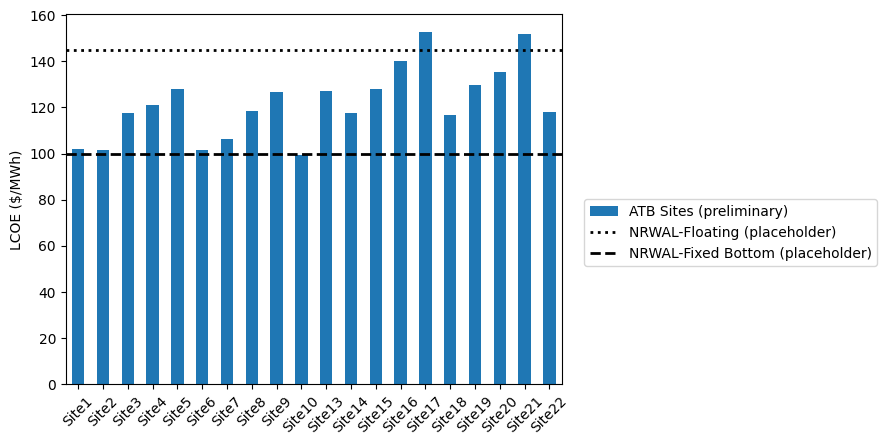

In [6]:
row = "LCOE ($/MWh)"
report_df_final.loc[row].plot(kind='bar', rot=45,label='ATB Sites (preliminary)')
plt.axhline(100, color='black', linestyle='--', linewidth=2, label='NRWAL-Fixed Bottom (placeholder)')
plt.axhline(145, color='black', linestyle=':', linewidth=2, label='NRWAL-Floating (placeholder)')

plt.ylabel(row)
plt.legend(bbox_to_anchor=(1.65, 0.3), loc='lower right', reverse=True)

In [7]:
def stacked_bar_chart(df, transpose=False, lpos=(1.5,0.5)):

    if transpose:
        df = df.T
        xticks = df.index
        ylabel = df.columns.name
    else:
        df = df
        xticks = df.columns
        ylabel = df.index.name

    df.plot(kind='bar', stacked=True)
    plt.xticks(rotation=45)
    plt.ylabel(ylabel)
    #plt.xlabel("ATB Site")

    plt.legend(bbox_to_anchor=lpos, loc='lower right', reverse=True)
    #plt.title(df.index.name)

    #plt.legend()

,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
CapEx ($/kW),,,,,,,,,,,,,,,,,,,,
Array System,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32,185.32
Array System Installation,216.13,215.11,213.62,217.28,217.28,215.11,215.11,217.28,217.28,215.11,412.28,405.62,405.62,411.45,411.45,405.62,405.62,411.45,411.45,405.62
Export System,274.69,227.34,132.63,795.34,463.83,227.34,227.46,795.34,463.83,227.34,212.98,233.01,236.82,533.63,535.85,233.01,236.82,533.63,535.85,233.01
Export System Installation,51.95,49.79,21.32,120.50,70.90,49.79,49.79,120.50,70.90,49.79,129.26,130.88,131.24,178.10,178.48,130.88,131.24,178.10,178.48,130.88
Mooring System,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,459.35,151.37,611.92,151.37,611.92,151.37,611.92,151.37,611.92,151.37
Mooring System Installation,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,153.38,111.12,160.65,114.08,190.46,111.12,160.65,114.08,190.46,111.12
Offshore Substation,224.98,223.84,753.22,237.49,753.22,223.84,223.84,237.49,753.22,223.84,223.38,223.84,223.84,753.22,753.22,223.84,223.84,753.22,753.22,223.84
Offshore Substation Installation,9.23,8.39,8.14,10.41,10.52,8.39,8.50,10.41,10.52,8.39,14.79,9.21,10.56,14.03,14.75,9.21,10.56,14.03,14.75,9.21
Project,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08,252.08


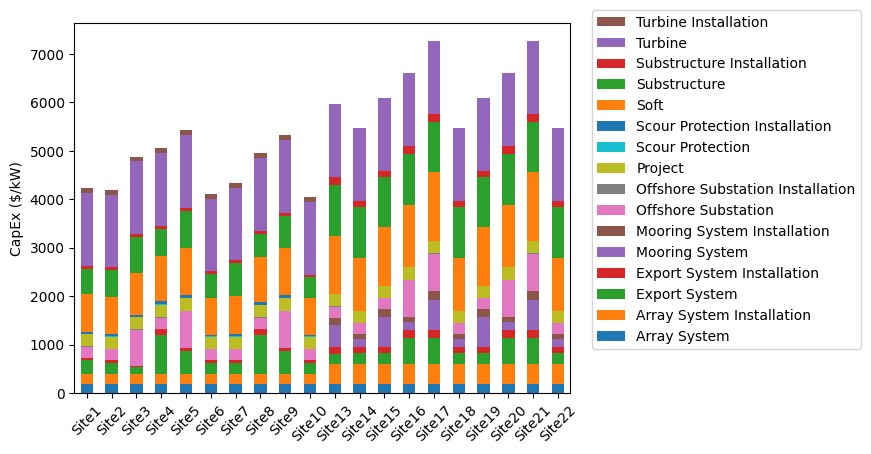

In [12]:
# Capture the CapEx breakdown for each reference site

report_capex_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.capex(breakdown=True,per_capacity="kw").drop(columns=["CapEx"])
    #print(_temp_df)
    _temp_df.columns = [f"{site_names[i]}"]

    #_temp_df[f"{site_names[i]} CapEx ($kW)"] = _temp_df[f"{site_names[i]} CapEx ($)"] / p.capacity("kw")

    report_capex_df = report_capex_df.join(_temp_df, how="outer").fillna(0.0)

#report_capex_df = report_capex_df / 1e6
report_capex_df.index.name = "CapEx ($/kW)"

report_capex_df.to_csv("reference_sites_capex_report.csv")

stacked_bar_chart(report_capex_df.drop("Total"), transpose=True, lpos=(1.6, 0.1))

report_capex_df


,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
Soft CapEx ($/kW),,,,,,,,,,,,,,,,,,,,
Commissioning,39.55,39.27,46.23,47.22,51.16,38.49,40.68,46.36,50.20,37.80,54.75,50.31,56.24,61.03,67.24,50.31,56.24,61.03,67.24,50.31
Construction Financing,258.01,255.79,300.50,311.66,336.11,250.47,265.13,305.61,329.77,245.98,370.94,338.48,379.14,412.33,455.69,338.48,379.14,412.33,455.69,338.48
Construction Insurance,70.16,69.66,82.01,83.77,90.76,68.27,72.16,82.24,89.05,67.06,97.13,89.24,99.76,108.26,119.28,89.24,99.76,108.26,119.28,89.24
Decommissioning,83.16,81.28,75.35,100.51,92.47,80.30,81.60,98.36,92.47,80.36,153.45,136.08,145.05,154.00,167.56,136.08,145.05,154.00,167.56,136.08
Installation Contingency,163.94,160.23,148.55,198.15,182.31,158.31,160.87,193.90,182.30,158.42,302.52,268.27,285.95,303.60,330.32,268.27,285.95,303.60,330.32,268.27
Procurement Contingency,170.44,169.64,206.38,203.08,225.43,166.05,176.58,199.49,220.61,162.61,223.35,206.82,233.52,254.54,281.15,206.82,233.52,254.54,281.15,206.82
Total,785.26,775.86,859.02,944.39,978.24,761.89,797.00,925.96,964.39,752.23,1202.15,1089.19,1199.65,1293.75,1421.25,1089.19,1199.65,1293.75,1421.25,1089.19


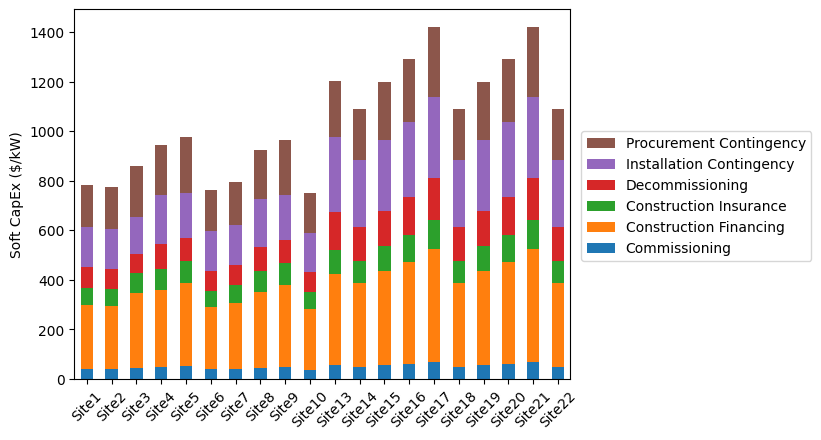

In [9]:
# Capture the Soft CapEx breakdown for each reference site

report_soft_capex_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.soft_capex(breakdown=True,per_capacity="kw").drop(columns=["Soft CapEx"])
    _temp_df.columns = [f"{site_names[i]}"]

    #_temp_df[f"{site_names[i]} Soft CapEx ($kW)"] = _temp_df[f"{site_names[i]} Soft CapEx ($)"] / p.capacity("kw")

    report_soft_capex_df = report_soft_capex_df.join(_temp_df, how="outer").fillna(0.0)

#report_soft_capex_df = report_soft_capex_df / 1e6
report_soft_capex_df.index.name = "Soft CapEx ($/kW)"

report_soft_capex_df.to_csv("reference_sites_soft_capex_report.csv")

stacked_bar_chart(report_soft_capex_df.drop("Total"), transpose=True,lpos=(1.5, 0.3))

report_soft_capex_df


,Site1,Site2,Site3,Site4,Site5,Site6,Site7,Site8,Site9,Site10,Site13,Site14,Site15,Site16,Site17,Site18,Site19,Site20,Site21,Site22
Losses (%),,,,,,,,,,,,,,,,,,,,
Availability Losses,6.92,6.91,7.16,7.30,6.87,7.15,7.07,6.62,6.95,6.96,8.62,8.65,8.13,8.99,8.61,8.56,8.76,7.53,8.46,8.70
Electrical Losses,3.52,3.35,3.37,3.98,4.00,3.35,3.37,3.98,4.00,3.35,3.71,3.43,3.94,4.06,4.57,3.43,3.94,4.06,4.57,3.43
Environmental Losses,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59,1.59
Technical Losses,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20,1.20
Total Losses,19.37,19.22,19.45,20.08,19.73,19.43,19.37,19.50,19.80,19.26,19.85,19.65,19.62,20.47,20.57,19.57,20.17,19.20,20.44,19.70
Wake Losses,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,7.84,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33,6.33


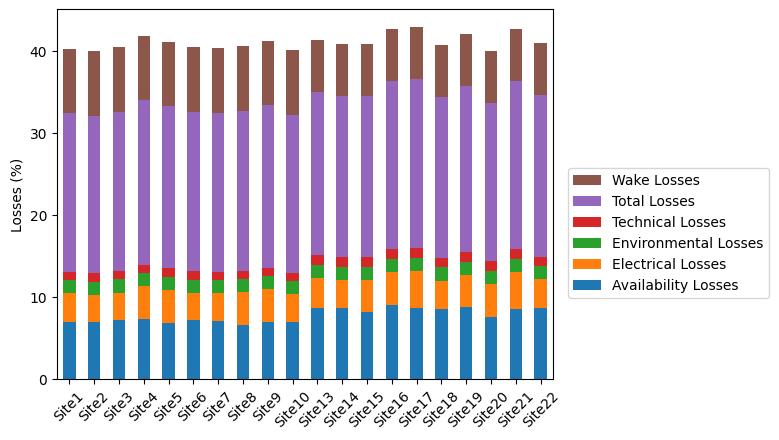

In [10]:
# Capture the Losses breakdown for each reference site

losses_report_df = pd.DataFrame()

for i,p in enumerate(project_list[:id]):

    _temp_df = p.loss_ratio(breakdown=True)
    _temp_df.columns =[f"{site_names[i]}"]

    losses_report_df = losses_report_df.join(_temp_df, how='outer').fillna(0.0)
    losses_report_df.index.name = "Losses (%)"

stacked_bar_chart(losses_report_df, transpose=True,lpos=(1.45, 0.2))

losses_report_df.to_csv("reference_sites_losses_report.csv")

losses_report_df
